In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
matches = pd.read_csv(r'C:\Users\hp\OneDrive\Documents\IPL_Data_Analysis_Folder\Data\matches.csv')

# Preview the data
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,18-04-2008,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,19-04-2008,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,19-04-2008,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,20-04-2008,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,20-04-2008,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1095 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [6]:
matches_per_season = matches['season'].value_counts().sort_index()

matches_per_season

season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: count, dtype: int64

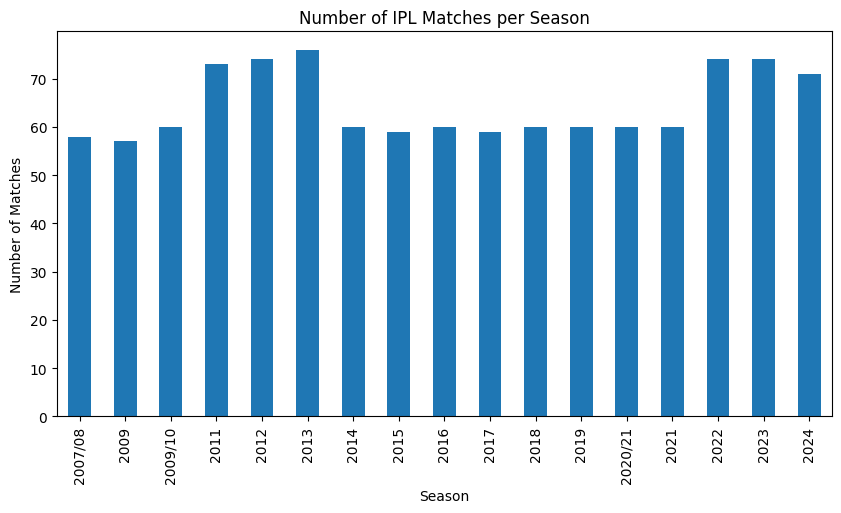

In [7]:
plt.figure(figsize=(10,5))
matches_per_season.plot(kind='bar')

plt.title("Number of IPL Matches per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")

plt.show()

In [8]:
team_wins = matches['winner'].value_counts()

team_wins

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
No Result                        5
Rising Pune Supergiants          5
Name: count, dtype: int64

In [9]:
wins_df = team_wins.reset_index()
wins_df.columns = ['team','wins']

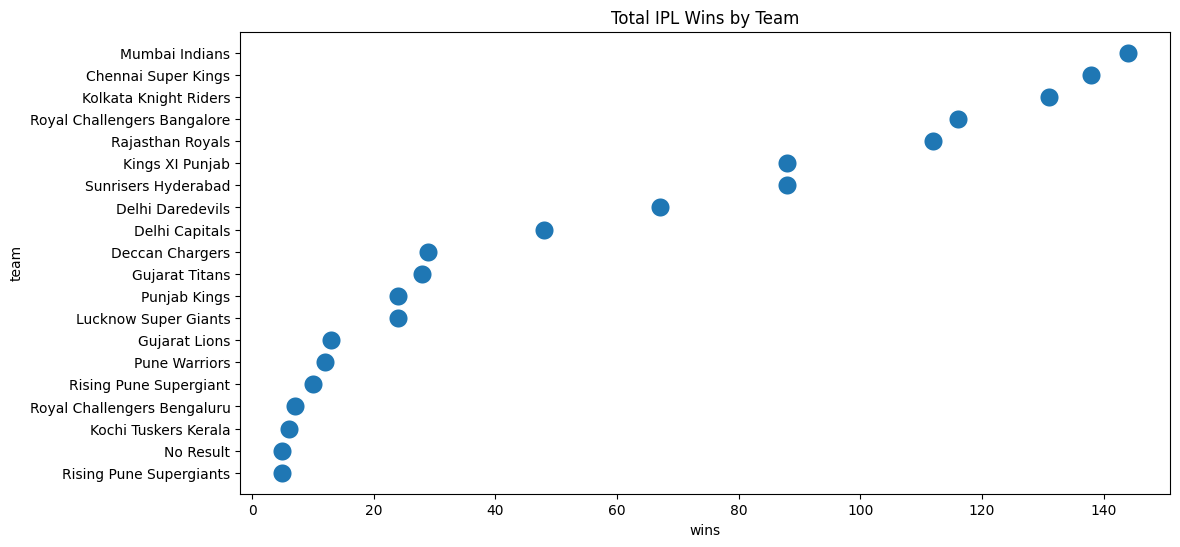

In [10]:
plt.figure(figsize=(12,6))

sns.scatterplot(data=wins_df, x='wins', y='team', s=200)

plt.title("Total IPL Wins by Team")

plt.show()

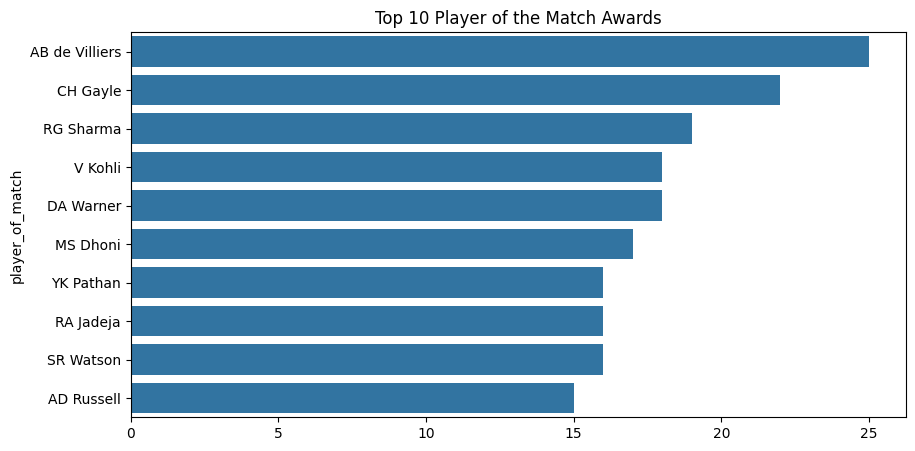

In [11]:
pom_counts = matches['player_of_match'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=pom_counts.values, y=pom_counts.index)
plt.title("Top 10 Player of the Match Awards")
plt.show()

In [15]:
deliveries = pd.read_csv(r'C:\Users\hp\OneDrive\Documents\IPL_Data_Analysis_Folder\Data\deliveries.csv')

strike_rate = deliveries.groupby('batter').agg(
    runs=('batsman_runs','sum'),
    balls=('ball','count')
)
strike_rate['SR'] = (strike_rate['runs']/strike_rate['balls'])*100


C:\Users\hp\AppData\Local\Temp\ipykernel_23732\3602886623.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  deliveries = pd.read_csv(r'C:\Users\hp\OneDrive\Documents\IPL_Data_Analysis_Folder\Data\deliveries.csv')


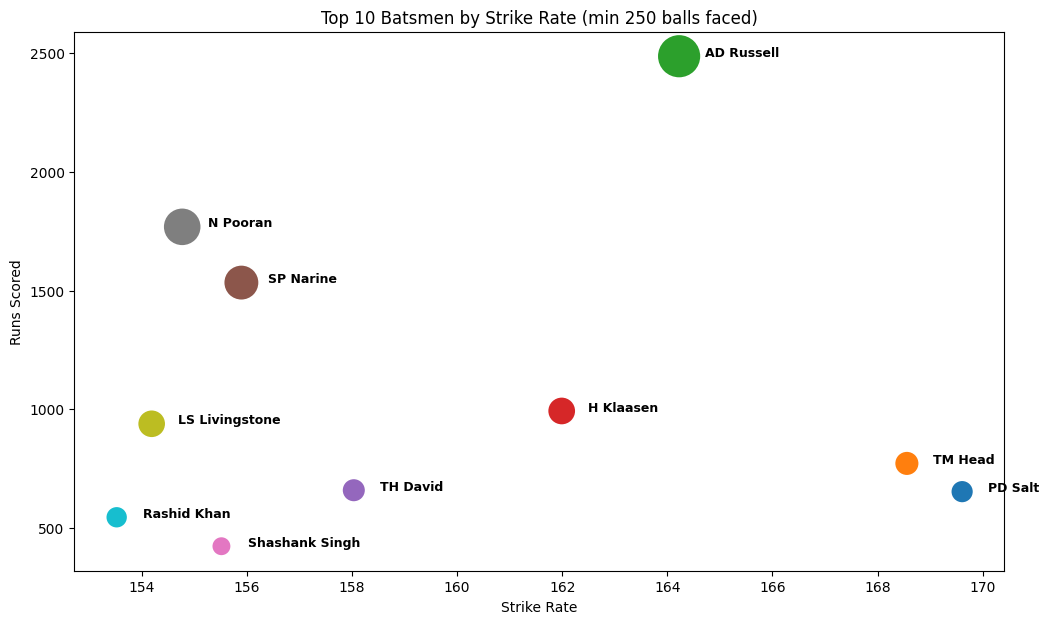

In [18]:
qualified = strike_rate[strike_rate['balls'] >= 250]

top10_sr = qualified.sort_values('SR', ascending=False).head(10)

plt.figure(figsize=(12,7))

# Bubble chart
sns.scatterplot(
    data=top10_sr,
    x='SR',
    y='runs',
    size='balls',
    hue=top10_sr.index,
    legend=False,
    sizes=(200,1000)
)

# Add labels for each batsman
for i in range(top10_sr.shape[0]):
    plt.text(
        x=top10_sr['SR'].iloc[i] + 0.5,   # small offset so text doesn’t overlap
        y=top10_sr['runs'].iloc[i],
        s=top10_sr.index[i],
        fontsize=9,
        weight='bold'
    )

plt.title("Top 10 Batsmen by Strike Rate (min 250 balls faced)")
plt.xlabel("Strike Rate")
plt.ylabel("Runs Scored")
plt.show()


In [28]:
death_overs = deliveries[deliveries['over'] >= 16]

In [29]:
death_stats = death_overs.groupby('bowler').agg(
    runs_conceded=('total_runs','sum'),
    balls_bowled=('ball','count')
).reset_index()

# Convert balls to overs
death_stats['overs'] = death_stats['balls_bowled'] / 6

# Economy rate = runs per over
death_stats['economy'] = death_stats['runs_conceded'] / death_stats['overs']


In [30]:
qualified_bowlers = death_stats[death_stats['overs'] >= 50]

In [31]:
top10_death_economy = qualified_bowlers.sort_values('economy').head(10)


C:\Users\hp\AppData\Local\Temp\ipykernel_23732\3159664938.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


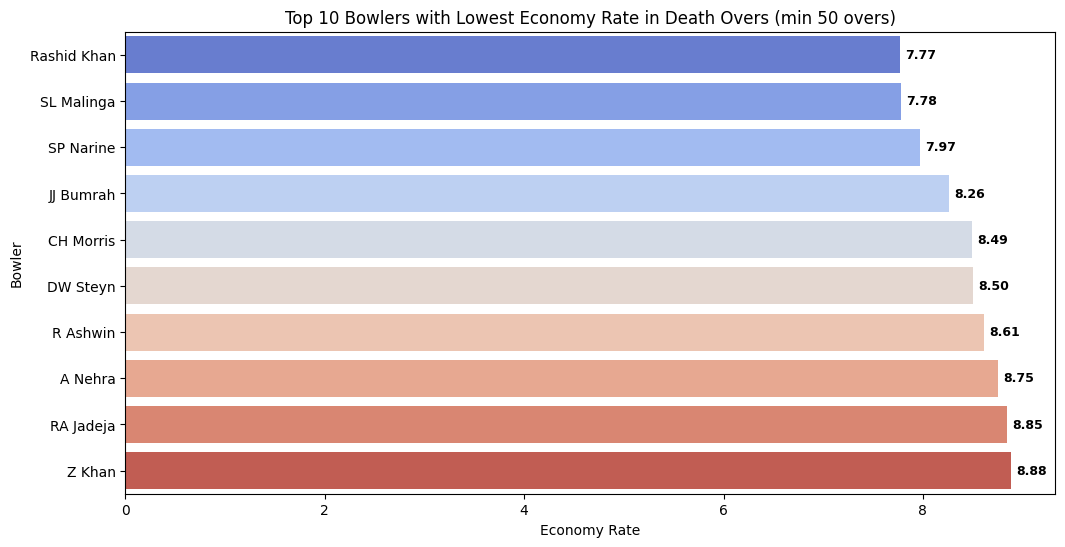

In [32]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top10_death_economy,
    x='economy',
    y='bowler',
    palette="coolwarm"
)

# Annotate economy values
for i, v in enumerate(top10_death_economy['economy']):
    plt.text(v + 0.05, i, f"{v:.2f}", va='center', fontsize=9, weight='bold')

plt.title("Top 10 Bowlers with Lowest Economy Rate in Death Overs (min 50 overs)")
plt.xlabel("Economy Rate")
plt.ylabel("Bowler")
plt.show()


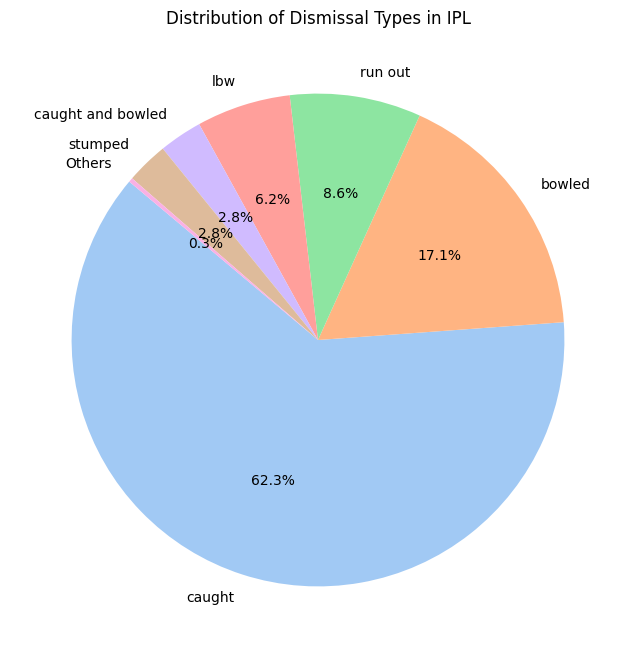

In [39]:

# Count dismissal types
dismissals = deliveries['dismissal_kind'].value_counts()

# Keep top 6, group the rest as 'Others'
top6 = dismissals.head(6)
others = dismissals.iloc[6:].sum()

# Combine into one series using concat
dismissals_pie = pd.concat([top6, pd.Series({'Others': others})])

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(
    dismissals_pie.values,
    labels=dismissals_pie.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("pastel")
)
plt.title("Distribution of Dismissal Types in IPL")
plt.show()
